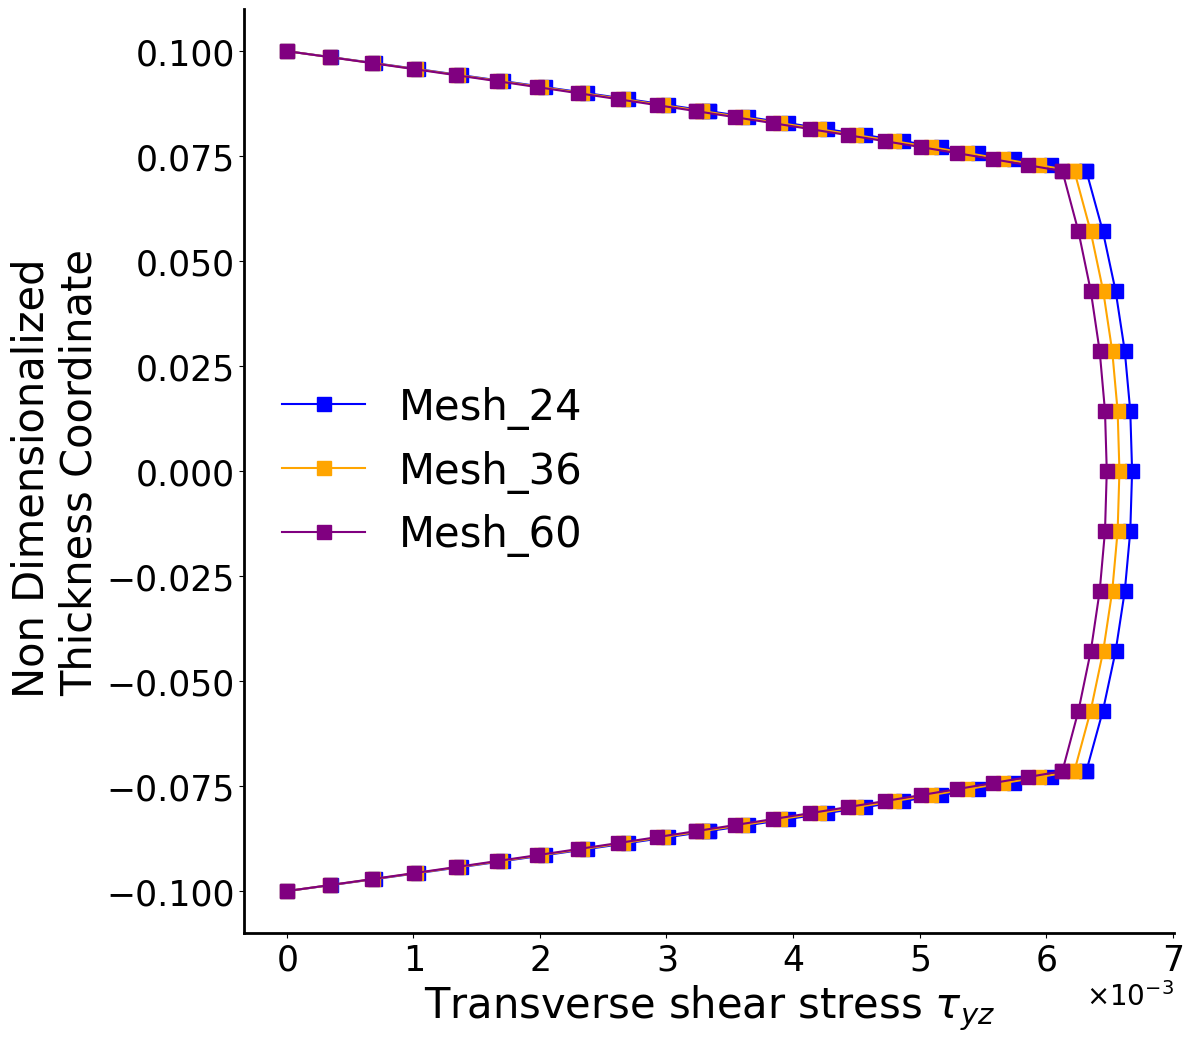

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plotter(file_path, X_axis_name=r'Inplane normal stress $\sigma_{x}$', legend_list=None):
    # Load and clean the data
    data = pd.read_csv(file_path, sep=',', skipinitialspace=True)
    data = data.drop(columns=[col for col in data.columns if 'Unnamed' in col])

    # Default legend list to column names if not provided
    if legend_list is None:
        legend_list = data.columns[::2]  # Use every second column name (stress columns)

    # Define colors and markers
    colors = ['blue', 'red', 'orange', 'magenta', 'purple', 'blue']
    markers = ['s'] * len(colors)  # Using square markers for all plots

    # Set up the plot
    plt.figure(figsize=(12, 12))
    for i in range(0, len(data.columns), 2):
        stress = data.columns[i]
        height = data.columns[i+1]
        label = legend_list[i//2] if i//2 < len(legend_list) else stress
        color = colors[i % len(colors)]
        plt.plot(data[stress], data[height], label=label, marker=markers[i % len(markers)], linestyle='-', color=color, markersize=10)
    
    fontsize = 30
    plt.xlabel(X_axis_name, fontsize=fontsize)
    plt.ylabel('Non Dimensionalized \nThickness Coordinate', fontsize=fontsize)
    plt.legend(fontsize=fontsize, frameon=False)
    plt.grid(False)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Increase axis line thickness
    ax = plt.gca()
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    # Use scientific notation for x-axis if the numbers are too small
    ax.xaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    # Set font size for tick labels and offset text
    ax.tick_params(axis='both', which='major', labelsize=fontsize-5)
    ax.xaxis.get_offset_text().set_fontsize(fontsize - 10)
    

    # Show the plot
    plt.show()

# Example usage with custom legend list
plotter(r'0900900SYZ.csv', X_axis_name=r'Transverse shear stress $\tau_{yz}$', legend_list=["Mesh_24", "Mesh_36", "Mesh_60"])


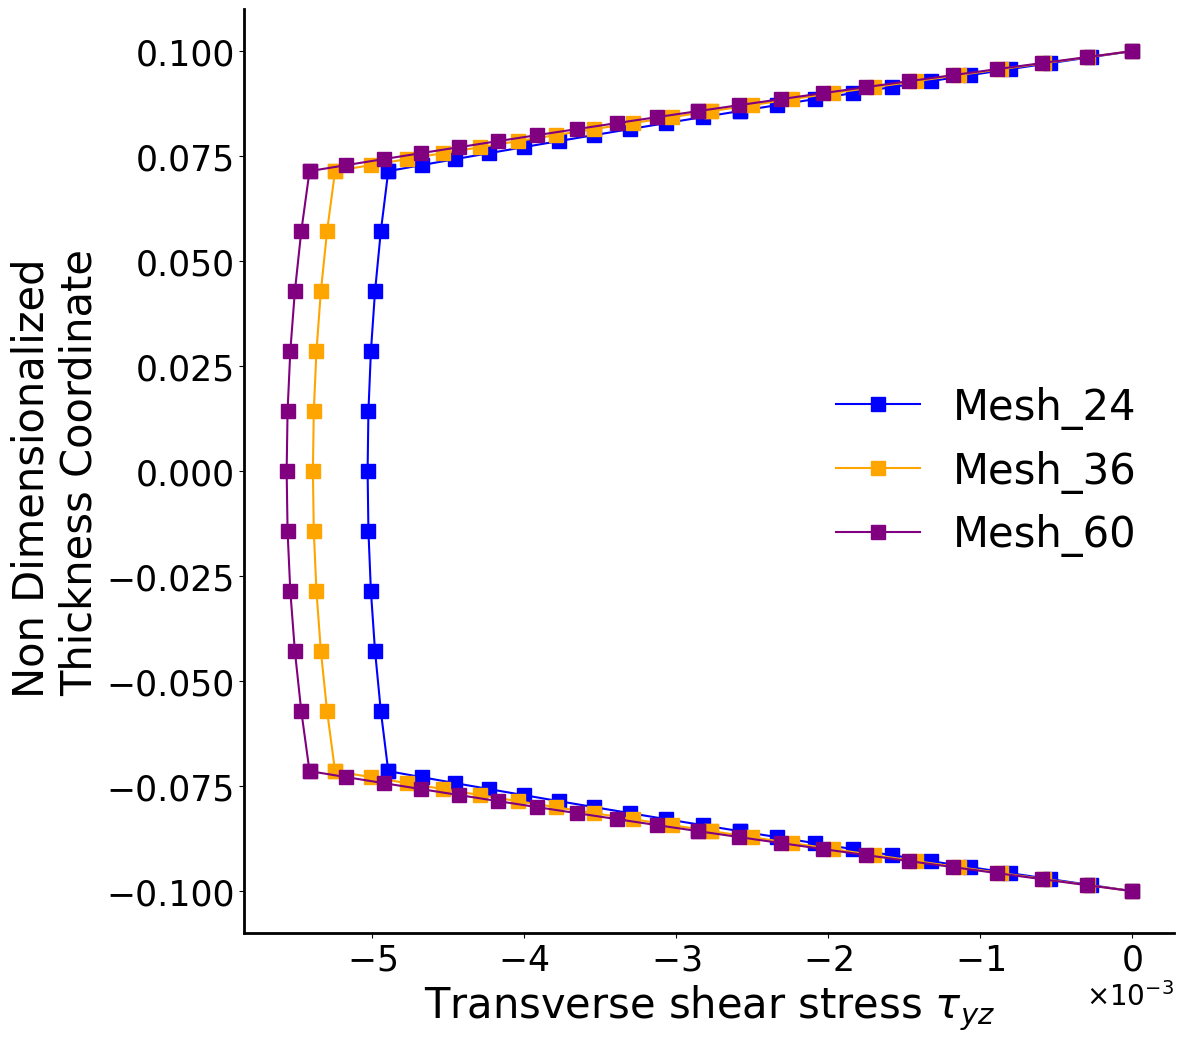

In [2]:
# Example usage with custom legend list
plotter(r'0900900SXZ.csv', X_axis_name=r'Transverse shear stress $\tau_{yz}$', legend_list=[ "Mesh_24", "Mesh_36", "Mesh_60"]) 

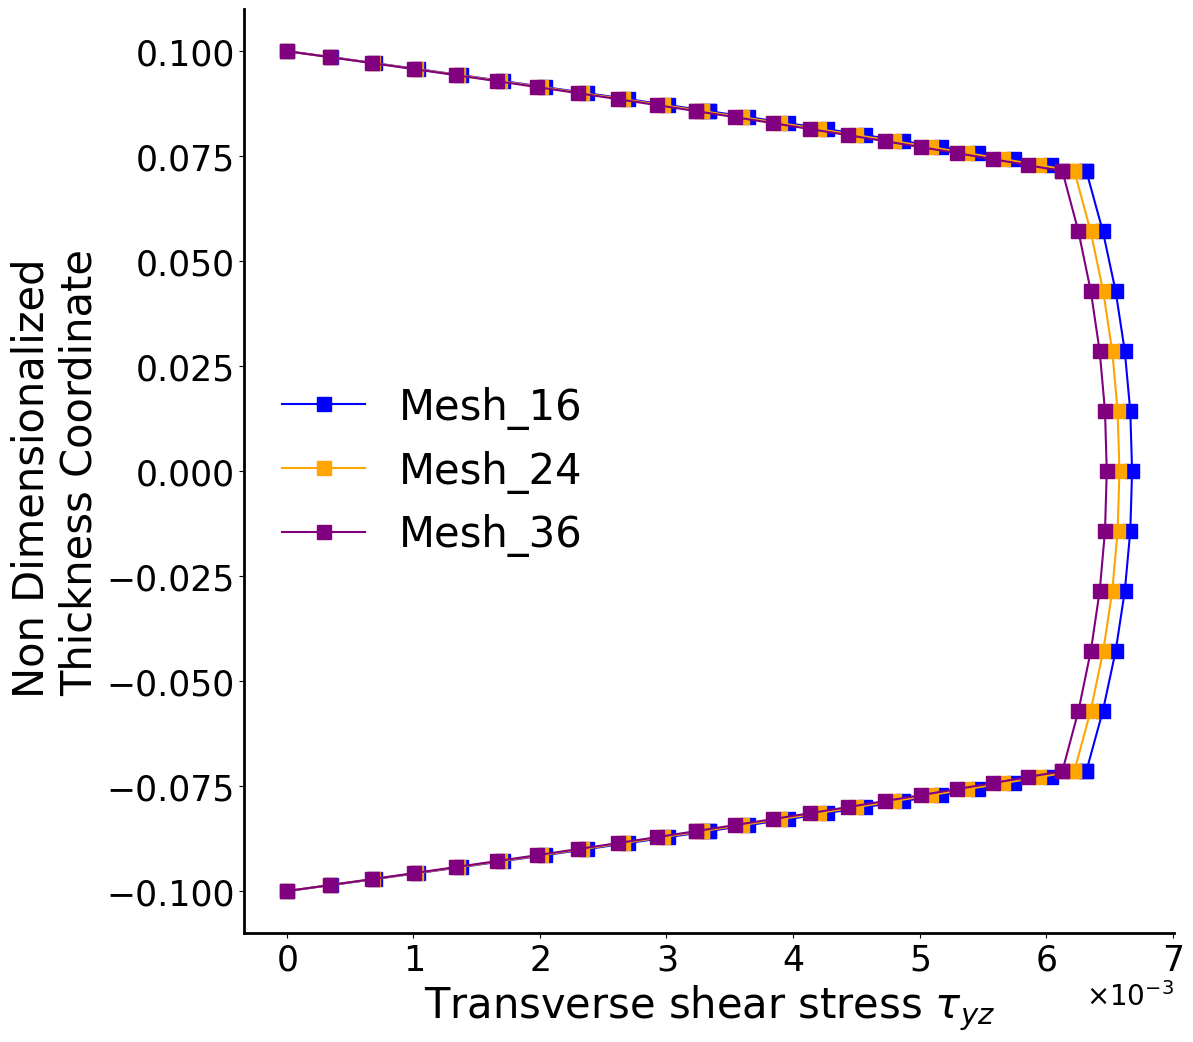

In [3]:


# Example usage
plotter(r'0900900SYZ.csv', X_axis_name=r'Transverse shear stress $\tau_{yz}$', legend_list=["Mesh_16", "Mesh_24", "Mesh_36", "Mesh_60"])
